In [19]:
import json
from pathlib import Path
from sweep_multihead_lightning import MultiHeadLightning, batch_to_tensor
from data_class import custom_collate
import torch 
import pickle
import numpy as np
import pandas as pd
import os

from scipy.stats import pearsonr



# Explicit Dataset and custom collate

In [20]:
from __future__ import annotations
import math, re
from dataclasses import dataclass
from typing import Any, Dict, Iterable, Optional, Tuple, List, Sequence
from typing import Literal
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset
from scipy.interpolate import RectBivariateSpline
from torch.utils.data._utils.collate import default_collate
import pickle

class ExplicitDataset(Dataset):
    """
    Test dataset that returns observed OD and label values
    without interpolation. One item = one (compound, t, c) row.
    """

    def __init__(self, df: pd.DataFrame, num_fourier: int):
        self.df = df.reset_index(drop=True)
        self.max_time = df["Timepoint"].max()
        self.num_fourier = int(num_fourier)

        # Collect fingerprint families
        self.fp_cols_by_family = sorted(
            [col for col in df.columns if col.endswith("_fp")]
        )

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx: int) -> Dict[str, Any]:
        row = self.df.iloc[idx]

        # Raw values
        t = float(row["Timepoint"])
        c = float(row["Concentration"])
        od = float(row["OD"])
        label = int(row["is_Active"])

        # Fourier time encoding
        t_prime=t-1
        T=15
        t_enc = np.zeros(2 * self.num_fourier, dtype=np.float32)
        for j, k_freq in enumerate(range(1, self.num_fourier + 1)):
            angle = 2 * np.pi * k_freq * t_prime / T
            t_enc[2 * j] = np.sin(angle)
            t_enc[2 * j + 1] = np.cos(angle)

        # Fingerprints
        features_by_family = {
            fam: torch.tensor(row[fam], dtype=torch.float32)
            for fam in self.fp_cols_by_family
        }

        return {
            "compound": row["Compound"],
            "smiles": row["Smiles"],
            "t_raw": torch.tensor(t, dtype=torch.float32),
            "t_fourier": torch.tensor(t_enc, dtype=torch.float32),
            "c_raw": torch.tensor(c, dtype=torch.float32),
            "c_log": torch.tensor(np.log(c), dtype=torch.float32),
            "y_reg": torch.tensor(od, dtype=torch.float32),
            "y_cls": torch.tensor(label, dtype=torch.float32),
            "features_by_family": features_by_family,
        }

def custom_collate(batch):
        """
        Custom collate function for PerCompoundDataset.

        Args:
            batch (list of dict): Each item is the output of __getitem__.

        Returns:
            dict: Batched output with stacked tensors and lists.
        """
        # Handle fingerprint features separately
        features_by_family = {}
        for fam in batch[0]['features_by_family'].keys():
            features_by_family[fam] = torch.stack(
                [item['features_by_family'][fam] for item in batch]
            )

        # Collate everything else using PyTorch’s default
        collated = {}
        for key in batch[0].keys():
            if key == 'features_by_family':
                continue
            collated[key] = default_collate([item[key] for item in batch])

        # Add fingerprints back
        collated['features_by_family'] = features_by_family
        return collated

# Load model and test set

In [21]:
#run_id = "mlshsq8w"   # good run
run_id= "uzknzsrt"
save_dir = Path(f"/home/ethan2/GrowthCurve/models/final_sweep/checkpoints/{run_id}")
# Load hyperparameters
with open(save_dir / "hparams.json") as f:
    hparams = json.load(f)

# Hardcoded input_dim mapping (t_fourier=6, c_raw=1, c_log=1 + fingerprint dims)
FEATURE_DIM_MAP = {
    "minimol":               520,   # 8 + 512
    "boltz2_minimol":       3592,   # 8 + 3072 + 512
    "minimol_classic":      4783,   # 8 + 512 + 2048 + 167 + 2048
    "boltz2_classic":       7343,   # 8 + 3072 + 2048 + 167 + 2048
    "boltz2_minimol_classic": 7855, # 8 + 3072 + 512 + 2048 + 167 + 2048
}
input_dim = FEATURE_DIM_MAP[hparams['feature_set']]

# Use the Celine dict (has minimol_fp + boltz2_rep needed by the model)
with open("/home/ethan2/GrowthCurve/data/test/dict_val_fourier_k_3_Celine.pkl", "rb") as f:
    dict_test_WT_mean = pickle.load(f)

Xte, y_reg, y_cls = batch_to_tensor(dict_test_WT_mean, torch.device("cpu"), feature_set=hparams['feature_set'])

# Load model
from sweep_multihead_lightning import MultiHeadLightning
model = MultiHeadLightning.load_from_checkpoint(
    save_dir / "best_params.ckpt",
    input_dim=input_dim,     # must match what you used during training
    config=hparams           # pass your loaded config
)
df_val   = pd.read_pickle("/home/ethan2/GrowthCurve/data/validation/df_well_validation_Celine_clusters_mad_4.pkl")
df_val['Concentration'].unique()

df_val_dense = pd.read_pickle('/home/ethan2/GrowthCurve/data/validation/df_well_validation_Celine_dense_timepoints_original_concs.pkl')

# Merge minimol_fp (and boltz2_rep) from smiles_representations.pkl into the
# validation DataFrames — they were built before these features were added.
with open("/home/ethan2/GrowthCurve/data/smiles_representations.pkl", "rb") as f:
    smiles_reps = pickle.load(f)

for _df in [df_val, df_val_dense]:
    for _feat in ["minimol_fp", "boltz2_rep"]:
        if _feat not in _df.columns:
            _df[_feat] = _df["Smiles"].map(lambda s: smiles_reps.get(s, {}).get(_feat))


# Functions

In [22]:
import numpy as np
import torch
from sklearn.metrics import roc_curve,roc_auc_score, average_precision_score, precision_score, recall_score,precision_recall_curve
import matplotlib.pyplot as plt

import torch
import numpy as np
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import roc_auc_score, average_precision_score

def plot_regression_classification_scatter(
    y_true, 
    y_pred, 
    y_cls_true, 
    y_cls_pred, 
    run_id,
    threshold=0.5, 
    save=None
):
    """
    Scatter plot of regression predictions vs ground truth,
    colored by classification outcomes (TP, TN, FP, FN).
    
    Args:
        y_true (array-like): Ground truth regression values.
        y_pred (array-like): Predicted regression values.
        y_cls_true (torch.Tensor or np.ndarray): Ground truth classification labels (0 or 1).
        y_cls_pred (torch.Tensor): Raw classification predictions (logits).
        threshold (float): Threshold to convert probabilities into binary predictions.
        run_id (str): Identifier for the model/run.
        save (bool or str): 
            - If False/None: show the plot.
            - If True: save to default location `/home/ethan2/GrowthCurve/plots/evaluate_models/{run_id}/scatter.png`.
            - If str: treat as a custom save path.
    """
    # Classification predictions
    y_cls_probs = torch.sigmoid(y_cls_pred).cpu().numpy().ravel()
    y_cls_labels = (y_cls_probs > threshold).astype(int)
    y_cls_true = np.array(y_cls_true).ravel().astype(int)
    
    # --- Metrics ---
    try:
        auroc = roc_auc_score(y_cls_true, y_cls_probs)
    except ValueError:
        auroc = float("nan")  # if only one class is present
    try:
        avpr = average_precision_score(y_cls_true, y_cls_probs)
    except ValueError:
        avpr = float("nan")

    # Masks
    tp_mask = (y_cls_true == 1) & (y_cls_labels == 1)
    tn_mask = (y_cls_true == 0) & (y_cls_labels == 0)
    fp_mask = (y_cls_true == 0) & (y_cls_labels == 1)
    fn_mask = (y_cls_true == 1) & (y_cls_labels == 0)
    
    # Counts
    tp_count = tp_mask.sum()
    tn_count = tn_mask.sum()
    fp_count = fp_mask.sum()
    fn_count = fn_mask.sum()
    
    # --- Plot ---
    plt.figure(figsize=(7, 7))
    plt.scatter(y_pred[tp_mask], y_true[tp_mask], c="green", alpha=0.6, edgecolor="k", 
                label=f"True Positive (n={tp_count})")
    plt.scatter(y_pred[tn_mask], y_true[tn_mask], c="blue", alpha=0.6, edgecolor="k", 
                label=f"True Negative (n={tn_count})")
    plt.scatter(y_pred[fp_mask], y_true[fp_mask], c="red", alpha=0.6, edgecolor="k", 
                label=f"False Positive (n={fp_count})")
    plt.scatter(y_pred[fn_mask], y_true[fn_mask], c="orange", alpha=0.6, edgecolor="k", 
                label=f"False Negative (n={fn_count})")
    
    # Reference diagonal
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    plt.plot(lims, lims, "k--", label="Ideal: y_true = y_pred")
    
    # Add metrics to legend
    plt.plot([], [], ' ', label=f"AUROC = {auroc:.3f}")
    plt.plot([], [], ' ', label=f"Avg Precision = {avpr:.3f}")
    
    plt.xlabel("Predicted OD (y_pred)")
    plt.ylabel("True OD (y_true)")
    plt.title(f"Model {run_id} - Regression vs Classification Scatter" if run_id else "Regression vs Classification Scatter")
    plt.legend()
    plt.grid(True)

    # --- Save or show ---
    if save:
        import os
        if isinstance(save, str):
            save_path = save
        else:
            save_dir = f"/home/ethan2/GrowthCurve/plots/evaluate_models/{run_id}"
            os.makedirs(save_dir, exist_ok=True)
            save_path = os.path.join(save_dir, f"Test_WT_scatter.png")
        
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
        plt.close()
        print(f"✅ Scatter plot saved at {save_path}")
    else:
        plt.show()


def get_misclassified_compounds(batch, y_cls_pred, threshold=0.5):
    """
    Identify compounds that are False Positives (FP) and False Negatives (FN).

    Args:
        batch (dict): Batch dictionary containing 'Compound' and 'y_cls' keys.
        y_cls_pred (torch.Tensor): Raw classification logits from the model.
        threshold (float): Probability threshold for classification (default=0.5).
    
    Returns:
        dict with lists of compounds in each category.
    """
    # Ground truth and predicted probabilities
    y_cls_true = np.array(batch["y_cls"]).ravel().astype(int)
    y_cls_probs = torch.sigmoid(y_cls_pred).cpu().numpy().ravel()
    y_cls_labels = (y_cls_probs > threshold).astype(int)

    # Compound names (ensure alignment)
    compounds = np.array(batch["compound"])

    # Masks
    fp_mask = (y_cls_true == 0) & (y_cls_labels == 1)
    fn_mask = (y_cls_true == 1) & (y_cls_labels == 0)

    # Extract compound names
    false_positives = np.unique(compounds[fp_mask])
    false_negatives = np.unique(compounds[fn_mask])

    # Report
    print(f"⚠️ False Positives ({len(false_positives)}):")
    print(false_positives)

    print(f"\n⚠️ False Negatives ({len(false_negatives)}):")
    print(false_negatives)

    return {
        "false_positives": list(false_positives),
        "false_negatives": list(false_negatives)
    }


    

    
    


def plot_roc_curve(y_true, y_probs, run_id, save=None):
    """
    Plot ROC curve and compute AUROC.

    Parameters
    ----------
    y_true : array-like
        Ground-truth binary labels (0/1).
    y_probs : array-like
        Predicted probabilities.
    title : str
        Title for the plot.
    """
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    auroc = roc_auc_score(y_true, y_probs)

    plt.figure(figsize=(6,6))
    plt.plot(fpr, tpr, color="darkorange", lw=2,
             label=f"ROC curve (AUROC = {auroc:.3f})")
    plt.plot([0,1], [0,1], color="navy", lw=2, linestyle="--",
             label="Random baseline")
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate (Recall)")
    plt.title(f"{run_id} : ROC curve")
    plt.legend(loc="lower right")
    plt.grid(True, linestyle="--", alpha=0.5)
    
    if save:
        if isinstance(save, str):
            save_path = save
        else:
            save_dir = f"/home/ethan2/GrowthCurve/plots/evaluate_models/{run_id}"
            os.makedirs(save_dir, exist_ok=True)
            save_path = os.path.join(save_dir, f"Test_WT_{run_id}_ROC_curve.png")
        
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
        plt.close()
        print(f"Plot saved at {save_path}")
    plt.show()
   

def plot_precision_by_threshold(y_true, y_probs, thresholds, run_id, save=None):
    """
    Plot precision as a function of threshold.
    """
    precisions = []
    for t in thresholds:
        preds = (y_probs > t).astype(int)
        precisions.append(precision_score(y_true, preds, zero_division=0))

    plt.figure(figsize=(6,5))
    plt.plot(thresholds, precisions, marker="o", color="blue")
    plt.xlabel("Threshold")
    plt.ylabel("Precision")
    plt.title(f'{run_id}:Precision by threhsold')
    
    if save:
        if isinstance(save, str):
            save_path = save
        else:
            save_dir = f"/home/ethan2/GrowthCurve/plots/evaluate_models/{run_id}"
            os.makedirs(save_dir, exist_ok=True)
            save_path = os.path.join(save_dir, f"Test_WT_{run_id}_Precision_by_threhsold.png")
        
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
        plt.close()
        print(f"Plot saved at {save_path}")
    plt.show()

    

import matplotlib.pyplot as plt
import os

def plot_precision_recall_curve(y_true, y_probs, run_id, save=None):
    """
    Plot Precision vs Recall curve.

    Args:
        y_true (array-like): True binary labels (0 or 1)
        y_probs (array-like): Predicted probabilities (floats in [0,1])
        run_id (str): Identifier for model/run
        save (bool or str): 
            - If False/None: show the plot
            - If True: save to default location /home/ethan2/GrowthCurve/plots/evaluate_models/{run_id}/
            - If str: treat as custom save path
    """
    # Compute precision-recall values
    precision, recall, thresholds = precision_recall_curve(y_true, y_probs)

    # Plot
    plt.figure(figsize=(6,5))
    plt.plot(recall, precision, color="blue", lw=2)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{run_id}: Precision–Recall Curve")
    plt.grid(True, linestyle="--", alpha=0.6)

    # Save or show
    if save:
        if isinstance(save, str):
            save_path = save
        else:
            save_dir = f"/home/ethan2/GrowthCurve/plots/evaluate_models/{run_id}"
            os.makedirs(save_dir, exist_ok=True)
            save_path = os.path.join(save_dir, f"Test_WT_{run_id}_Precision_Recall_Curve.png")
        
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
        plt.close()
        print(f"Plot saved at {save_path}")
    else:
        plt.show()


def plot_recall_by_threshold(y_true, y_probs, thresholds, run_id, save=None):
    """
    Plot recall as a function of threshold.
    """
    recalls = []
    for t in thresholds:
        preds = (y_probs > t).astype(int)
        recalls.append(recall_score(y_true, preds, zero_division=0))

    plt.figure(figsize=(6,5))
    plt.plot(thresholds, recalls, marker="o", color="red")
    plt.xlabel("Threshold")
    plt.ylabel("Recall")
    plt.title("Recall vs Threshold")
    plt.grid(True, linestyle="--", alpha=0.5)

    if save:
        if isinstance(save, str):
            save_path = save
        else:
            save_dir = f"/home/ethan2/GrowthCurve/plots/evaluate_models/{run_id}"
            os.makedirs(save_dir, exist_ok=True)
            save_path = os.path.join(save_dir, f"Test_WT_{run_id}_Recall_vs_Threshold.png")
        
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
        plt.close()
        print(f"Plot saved at {save_path}")
    plt.show()


def plot_enrichment_by_threshold(y_true, y_probs, thresholds, run_id, save=None):
    """
    Plot enrichment factor as a function of threshold.
    EF = (fraction of actives among predicted positives) / (overall active fraction)
    """
    n_actives = np.sum(y_true)
    frac_actives = n_actives / len(y_true)
    
    enrichments = []
    for t in thresholds:
        preds = (y_probs > t).astype(int)
        if preds.sum() == 0 or frac_actives == 0:
            ef = 0.0
        else:
            frac_in_top = np.sum(y_true[preds == 1]) / preds.sum()
            ef = frac_in_top / frac_actives
        enrichments.append(ef)

    plt.figure(figsize=(6,5))
    plt.plot(thresholds, enrichments, marker="o", color="purple")
    plt.axhline(1.0, color="k", linestyle="--", label="Random baseline (EF=1)")
    plt.xlabel("Threshold")
    plt.ylabel("Enrichment Factor (EF)")
    plt.title(f"{run_id}:Enrichment vs Threshold")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    if save:
        if isinstance(save, str):
            save_path = save
        else:
            save_dir = f"/home/ethan2/GrowthCurve/plots/evaluate_models/{run_id}"
            os.makedirs(save_dir, exist_ok=True)
            save_path = os.path.join(save_dir, f"Test_WT_{run_id}_Enrichment_vs_Threshold.png")
        
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
        plt.close()
        print(f"Plot saved at {save_path}")
    plt.show()


def get_probs(y_logits: torch.Tensor) -> np.ndarray:
    """Apply sigmoid to logits and return numpy probabilities."""
    return torch.sigmoid(y_logits).cpu().numpy().ravel()

def compute_auroc(y_true: np.ndarray, y_probs: np.ndarray) -> float:
    return roc_auc_score(y_true, y_probs)

def compute_avpr(y_true: np.ndarray, y_probs: np.ndarray) -> float:
    return average_precision_score(y_true, y_probs)

def compute_precision_recall(y_true: np.ndarray, y_probs: np.ndarray, thresholds: list[float]):
    """Compute precision & recall for each threshold."""
    results = {}
    for t in thresholds:
        preds = (y_probs > t).astype(int)
        prec = precision_score(y_true, preds, zero_division=0)
        rec  = recall_score(y_true, preds, zero_division=0)
        results[t] = {"precision": prec, "recall": rec}
    return results

def compute_enrichment(y_true: np.ndarray, y_probs: np.ndarray, thresholds: list[float]):
    """
    Enrichment factor at each threshold.
    EF = (fraction of actives retrieved up to threshold) / (overall fraction of actives)
    """
    enrichment = {}
    n_actives = np.sum(y_true)
    frac_actives = n_actives / len(y_true)

    for t in thresholds:
        preds = (y_probs > t).astype(int)
        if preds.sum() == 0:
            ef = 0.0
        else:
            frac_actives_found = np.sum(y_true[preds == 1]) / preds.sum()
            ef = frac_actives_found / frac_actives if frac_actives > 0 else 0.0
        enrichment[t] = ef
    return enrichment

def plot_od_histogram(y_pred_reg: torch.Tensor, y_true_cls: torch.Tensor, run_id, save=None,bins: int = 30):
    """
    Plot histogram of predicted OD values, colored by activity.
    
    Parameters
    ----------
    y_pred_reg : torch.Tensor
        Regression predictions (OD values).
    y_true_cls : torch.Tensor
        True binary activity labels (0 = inactive, 1 = active).
    bins : int
        Number of histogram bins (default = 30).
    """
    # Convert to numpy
    y_pred = y_pred_reg.cpu().numpy().ravel()
    y_cls = y_true_cls.cpu().numpy().ravel()

    # Split into active vs inactive
    inactive = y_pred[y_cls == 0]
    active   = y_pred[y_cls == 1]

    plt.figure(figsize=(8,6))
    plt.hist(inactive, bins=bins, alpha=0.6, color="blue", label="Inactive")
    plt.hist(active, bins=bins, alpha=0.6, color="red", label="Active")

    plt.xlabel("Predicted OD")
    plt.ylabel("Count of compounds")
    plt.title(f"{run_id} : Distribution of Predicted OD by Activity on WT")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    if save:
        if isinstance(save, str):
            save_path = save
        else:
            save_dir = f"/home/ethan2/GrowthCurve/plots/evaluate_models/{run_id}"
            os.makedirs(save_dir, exist_ok=True)
            save_path = os.path.join(save_dir, f"Test_WT_{run_id}_Distribution_of_Predicted_OD_by_Activity.png")
        
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
        plt.close()
        print(f"Plot saved at {save_path}")
    plt.show()

def plot_logit_histogram(y_pred_logits: torch.Tensor, y_true_cls: torch.Tensor,run_id,save=None, bins: int = 30):
    """
    Plot histogram of classification logits, colored by activity.

    Parameters
    ----------
    y_pred_logits : torch.Tensor
        Raw logits from classification head.
    y_true_cls : torch.Tensor
        True binary activity labels (0 = inactive, 1 = active).
    bins : int
        Number of histogram bins (default = 30).
    """
    # Convert to numpy
    y_logits = y_pred_logits.cpu().numpy().ravel()
    y_cls = y_true_cls.cpu().numpy().ravel()

    # Split logits
    inactive = y_logits[y_cls == 0]
    active   = y_logits[y_cls == 1]

    plt.figure(figsize=(8,6))
    plt.hist(inactive, bins=bins, alpha=0.6, color="blue", label="Inactive")
    plt.hist(active, bins=bins, alpha=0.6, color="red", label="Active")

    # Add vertical line at 0 (the decision boundary in logit space)
    plt.axvline(0, color="k", linestyle="--", linewidth=2, label="Logit=0 (p=0.5)")

    plt.xlabel("Predicted Logit (classification head)")
    plt.ylabel("Count of compounds")
    plt.title("Distribution of Classification Logits by Activity on WT")
    plt.legend()

    if save:
        if isinstance(save, str):
            save_path = save
        else:
            save_dir = f"/home/ethan2/GrowthCurve/plots/evaluate_models/{run_id}"
            os.makedirs(save_dir, exist_ok=True)
            save_path = os.path.join(save_dir, f"Test_WT_{run_id}_Distribution_of_Classification_Logits_by_Activity.png")
        
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
        plt.close()
        print(f"Plot saved at {save_path}")
    plt.show()




# Evaluate on Validation set

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
from torchmetrics.functional import mean_absolute_error, pearson_corrcoef, auroc, average_precision, recall
from torch.utils.data import DataLoader
from tqdm import tqdm

def plot_model_heatmaps(
    df_val,
    model,
    id,
    ExplicitDataset,
    custom_collate,
    batch_to_tensor,
    feature_set="minimol",
    num_fourier=3,
    device="cuda",
    activity=None,
    save=False
):
    """
    Generate heatmaps of model performance metrics across (Timepoint, Concentration).

    Args:
        df_val (pd.DataFrame): Validation dataframe with OD, is_Active, Timepoint, Concentration, etc.
        model (torch.nn.Module): Trained model for inference.
        id (str): Run identifier.
        ExplicitDataset (Dataset class): Dataset class used for inference.
        custom_collate (callable): Collate function for DataLoader.
        batch_to_tensor (callable): Converts collated dict to tensors.
        num_fourier (int): Fourier encoding dimension used in your dataset.
        device (str): 'cuda' or 'cpu'.
        activity (int or None): Optional filter for regression metrics (1=actives only, 0=inactives only).
        save (bool or str): Whether to save the plots. If True, saves to default dir.
    """
    model.eval()

    # Extract all unique values
    timepoints = sorted(df_val["Timepoint"].unique())
    concentrations = sorted(df_val["Concentration"].unique())

    # Prepare empty metric grids
    metrics = {
        "AUC": np.full((len(timepoints), len(concentrations)), np.nan),
        "AP": np.full((len(timepoints), len(concentrations)), np.nan),
        "Recall": np.full((len(timepoints), len(concentrations)), np.nan),
        "MAE": np.full((len(timepoints), len(concentrations)), np.nan),
        "Pearson": np.full((len(timepoints), len(concentrations)), np.nan),
    }

    # --- Main loop ---
    for i, t in enumerate(tqdm(timepoints, desc="Timepoints")):
        for j, c in enumerate(concentrations):
            df_subset = df_val[(df_val["Timepoint"] == t) & (df_val["Concentration"] == c)]
            if df_subset.empty:
                print(f"⚠️ No data for Timepoint={t}, Concentration={c}")
                continue

            try:
                ds_test = ExplicitDataset(df_subset, num_fourier=num_fourier)
                test_loader = DataLoader(ds_test, batch_size=len(ds_test), collate_fn=custom_collate)
                dict_test = next(iter(test_loader))
            except Exception:
                continue

            # Convert to tensors
            Xte, y_reg, y_cls = batch_to_tensor(dict_test, torch.device(device), feature_set=feature_set)
            if len(y_cls) == 0:
                continue

            # --- Inference ---
            with torch.no_grad():
                y_reg_pred, y_cls_pred = model(Xte.to(device))

            # --- Extract numpy arrays ---
            y_true_cls = y_cls.cpu().numpy().ravel().astype(int)
            y_pred_cls = torch.sigmoid(y_cls_pred).cpu().numpy().ravel()
            y_true_reg = y_reg.cpu().numpy().ravel()
            y_pred_reg = y_reg_pred.cpu().numpy().ravel()

            # --- Classification metrics ---
            if len(np.unique(y_true_cls)) > 1:
                metrics["AUC"][i, j] = auroc(torch.tensor(y_pred_cls), torch.tensor(y_true_cls), task="binary").item()
                metrics["AP"][i, j] = average_precision(torch.tensor(y_pred_cls), torch.tensor(y_true_cls), task="binary").item()
                metrics["Recall"][i, j] = recall(torch.tensor(y_pred_cls > 0.5), torch.tensor(y_true_cls), task="binary").item()

            # --- Regression metrics ---
            if activity == 1:
                mask = (y_true_cls == 1)  # actives only
            else:
                mask = np.ones_like(y_true_reg, dtype=bool)  # whole set (no filtering)

            if mask.sum() > 1:
                y_t = torch.tensor(y_true_reg[mask])
                y_p = torch.tensor(y_pred_reg[mask])
                metrics["MAE"][i, j] = mean_absolute_error(y_p, y_t).item()
                try:
                    metrics["Pearson"][i, j] = pearson_corrcoef(y_p, y_t).item()
                except Exception:
                    pass

    # --- Plot and Save ---
    save_dir = f"/home/ethan2/GrowthCurve/plots/evaluate_models/{id}"
    if save:
        os.makedirs(save_dir, exist_ok=True)

    for metric_name, mat in metrics.items():
        mean_val = np.nanmean(mat)

        # Label for actives/inactives (only for regression)
        reg_suffix = ""
        if activity == 1 and metric_name in ["MAE", "Pearson"]:
            reg_suffix = " (on actives)"
        elif activity == 0 and metric_name in ["MAE", "Pearson"]:
            reg_suffix = " (whole set)"

        plt.figure(figsize=(8, 6))
        sns.heatmap(
            mat.T,
            cmap="viridis",
            vmin=0.0, vmax=1.0 if metric_name != "MAE" else None,
            xticklabels=[str(t) for t in timepoints],
            yticklabels=[str(c) for c in concentrations],
            annot=True, fmt=".2f",
            cbar_kws={"label": metric_name},
        )
        plt.title(f"{id} — Validation {metric_name}{reg_suffix} (mean = {mean_val:.3f})")
        plt.xlabel("Timepoint")
        plt.ylabel("Concentration")
        plt.tight_layout()

        if save:
            save_path = os.path.join(save_dir, f"validation_{metric_name}_activity_{activity}.png")
            plt.savefig(save_path, bbox_inches="tight", dpi=300)
            plt.close()
            print(f"✅ Saved: {save_path}")
        else:
            plt.show()


plot_model_heatmaps(
    df_val=df_val,
    model=model,
    id=run_id,
    ExplicitDataset=ExplicitDataset,
    custom_collate=custom_collate,
    batch_to_tensor=batch_to_tensor,
    feature_set=hparams['feature_set'],
    num_fourier=3,
    device="cuda",
    activity=1,
    save=False
)



/home/ethan2/local/conda/envs/my_conda_env/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


NameError: name 'df_val' is not defined

In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score, average_precision_score

def plot_model_scatter_from_df(
    df_val,
    model,
    run_id,
    ExplicitDataset,
    custom_collate,
    batch_to_tensor,
    feature_set="minimol",
    num_fourier=3,
    device="cuda",
    concentrations=None,
    timepoints=None,
    threshold=0.5,
    save=False
):
    """
    Scatter plot of regression predictions vs ground truth, colored by classification outcomes (TP, TN, FP, FN),
    using a pandas DataFrame input like in plot_model_heatmaps.

    Args:
        df_val (pd.DataFrame): Validation dataframe with OD, is_Active, Timepoint, Concentration, etc.
        model (torch.nn.Module): Trained model for inference.
        run_id (str): Identifier for the model/run.
        ExplicitDataset (Dataset class): Dataset class used for inference.
        custom_collate (callable): Collate function for DataLoader.
        batch_to_tensor (callable): Converts collated dict to tensors.
        num_fourier (int): Fourier encoding dimension used in your dataset.
        device (str): 'cuda' or 'cpu'.
        concentrations (list, array, or None): List of concentrations to include. If None, uses all.
        timepoints (list, array, or None): List of timepoints to include. If None, uses all.
        threshold (float): Threshold to convert probabilities into binary predictions.
        save (bool or str): Whether to save plot.
            - If True, saves to default path `/home/ethan2/GrowthCurve/plots/evaluate_models/{run_id}/scatter_[filters].png`
            - If str, saves directly to that path.
            - If False/None, shows the plot.
    """
    model.eval()

    # ---- Default ranges ----
    if concentrations is None:
        concentrations = sorted(df_val["Concentration"].unique())
    if timepoints is None:
        timepoints = sorted(df_val["Timepoint"].unique())

    # ---- Filter DataFrame ----
    df_subset = df_val[df_val["Concentration"].isin(concentrations) & df_val["Timepoint"].isin(timepoints)]
    if df_subset.empty:
        print(f"⚠️ No data available for the selected concentrations/timepoints.")
        return

    # ---- Dataset + DataLoader ----
    ds_test = ExplicitDataset(df_subset, num_fourier=num_fourier)
    test_loader = DataLoader(ds_test, batch_size=len(ds_test), collate_fn=custom_collate)
    dict_test = next(iter(test_loader))
    Xte, y_reg, y_cls = batch_to_tensor(dict_test, torch.device(device), feature_set=feature_set)
    if len(y_cls) == 0:
        print("⚠️ Empty classification labels — skipping.")
        return

    # ---- Inference ----
    with torch.no_grad():
        y_reg_pred, y_cls_pred = model(Xte.to(device))

    # ---- Convert to numpy ----
    y_true = y_reg.cpu().numpy().ravel()
    y_pred = y_reg_pred.cpu().numpy().ravel()
    y_cls_true = y_cls.cpu().numpy().ravel().astype(int)
    y_cls_probs = torch.sigmoid(y_cls_pred).cpu().numpy().ravel()
    y_cls_labels = (y_cls_probs > threshold).astype(int)

    # ---- Metrics ----
    try:
        auroc = roc_auc_score(y_cls_true, y_cls_probs)
    except ValueError:
        auroc = float("nan")
    try:
        avpr = average_precision_score(y_cls_true, y_cls_probs)
    except ValueError:
        avpr = float("nan")

    # ---- Masks ----
    tp_mask = (y_cls_true == 1) & (y_cls_labels == 1)
    tn_mask = (y_cls_true == 0) & (y_cls_labels == 0)
    fp_mask = (y_cls_true == 0) & (y_cls_labels == 1)
    fn_mask = (y_cls_true == 1) & (y_cls_labels == 0)

    # ---- Counts ----
    tp_count, tn_count, fp_count, fn_count = map(np.sum, [tp_mask, tn_mask, fp_mask, fn_mask])

    # ---- Plot ----
    plt.figure(figsize=(7, 7))
    plt.scatter(y_pred[tp_mask], y_true[tp_mask], c="green", alpha=0.6, edgecolor="k",
                label=f"True Positive (n={tp_count})")
    plt.scatter(y_pred[tn_mask], y_true[tn_mask], c="blue", alpha=0.6, edgecolor="k",
                label=f"True Negative (n={tn_count})")
    plt.scatter(y_pred[fp_mask], y_true[fp_mask], c="red", alpha=0.6, edgecolor="k",
                label=f"False Positive (n={fp_count})")
    plt.scatter(y_pred[fn_mask], y_true[fn_mask], c="orange", alpha=0.6, edgecolor="k",
                label=f"False Negative (n={fn_count})")

    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    plt.plot(lims, lims, "k--", label="Ideal: y_true = y_pred")

    plt.plot([], [], ' ', label=f"AUROC = {auroc:.3f}")
    plt.plot([], [], ' ', label=f"Avg Precision = {avpr:.3f}")

    # Title formatting
    conc_str = ", ".join(map(str, concentrations))
    time_str = ", ".join(map(str, timepoints))
    plt.title(f"Model {run_id} — Scatter | Conc=[{conc_str}] | Time=[{time_str}]")
    plt.xlabel("Predicted OD (y_pred)")
    plt.ylabel("True OD (y_true)")
    plt.legend()
    plt.grid(True)

    # ---- Save or Show ----
    if save:
        if isinstance(save, str):
            save_path = save
        else:
            save_dir = f"/home/ethan2/GrowthCurve/plots/evaluate_models/{run_id}"
            os.makedirs(save_dir, exist_ok=True)
            conc_tag = "_".join(map(str, concentrations))
            time_tag = "_".join(map(str, timepoints))
            save_path = os.path.join(save_dir, f"Validation_WT_scatter_conc_{conc_tag}_all_times.png")

        plt.savefig(save_path, bbox_inches="tight", dpi=300)
        plt.close()
        print(f"✅ Saved scatter plot at {save_path}")
    else:
        plt.show()


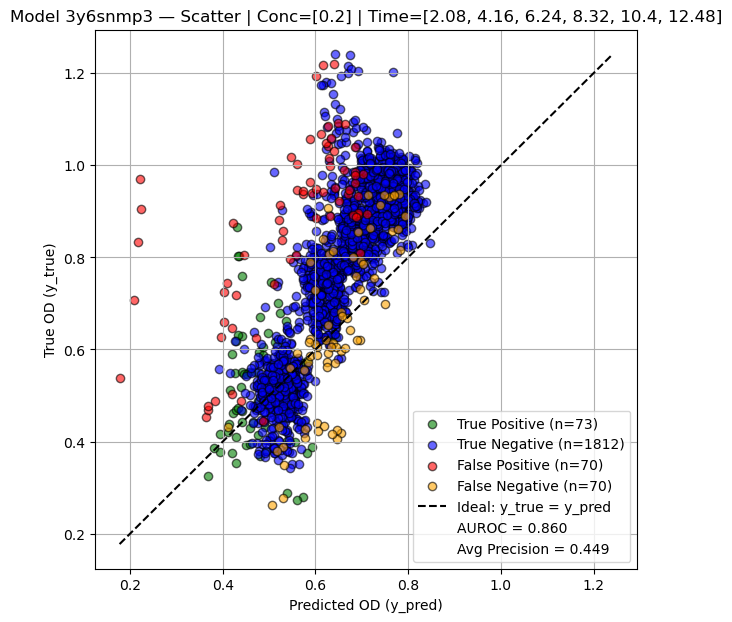

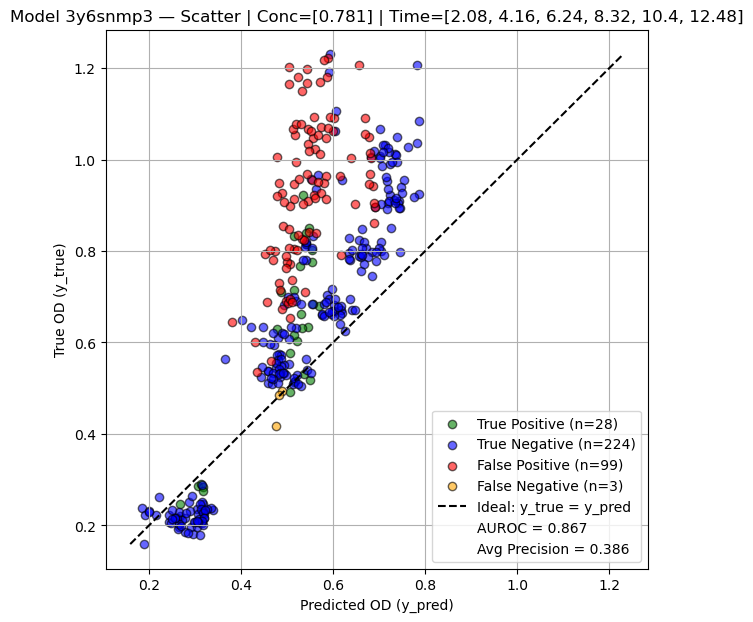

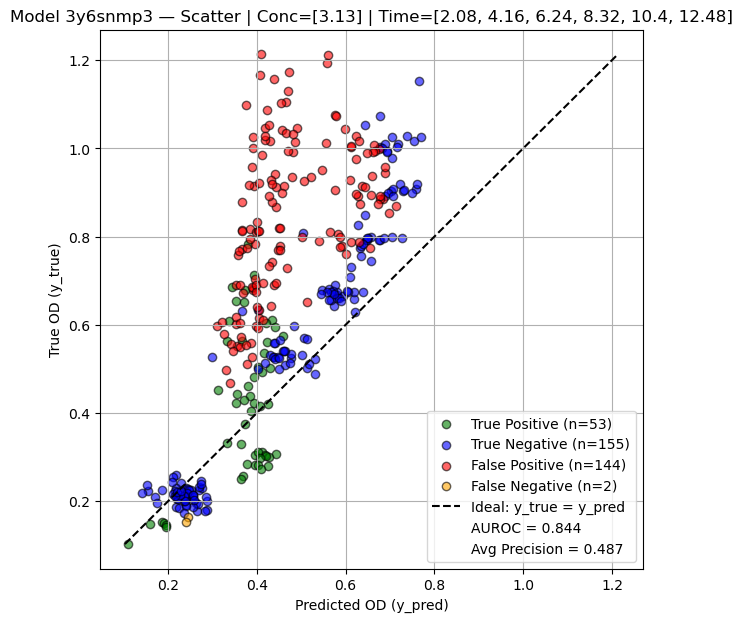

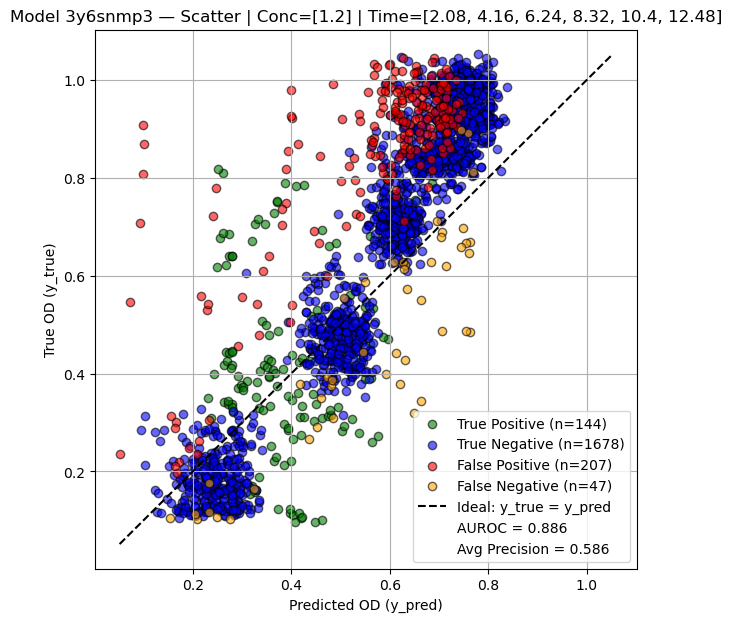

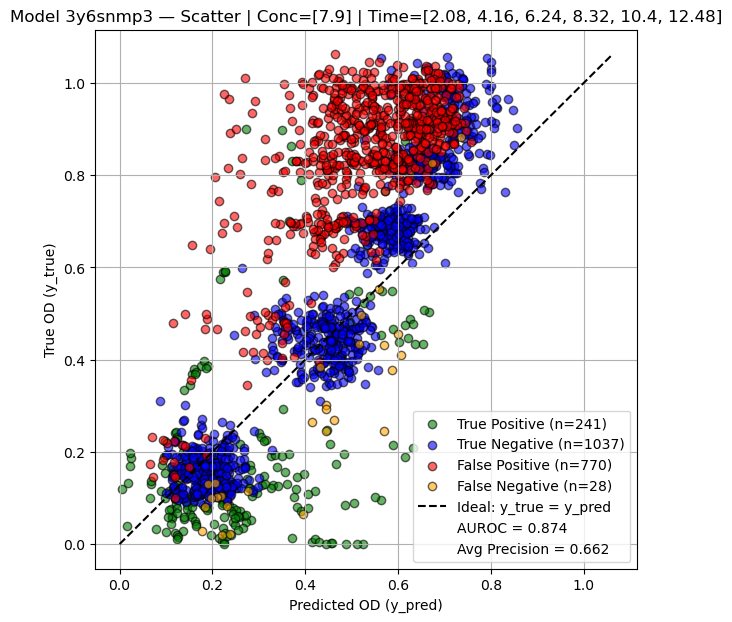

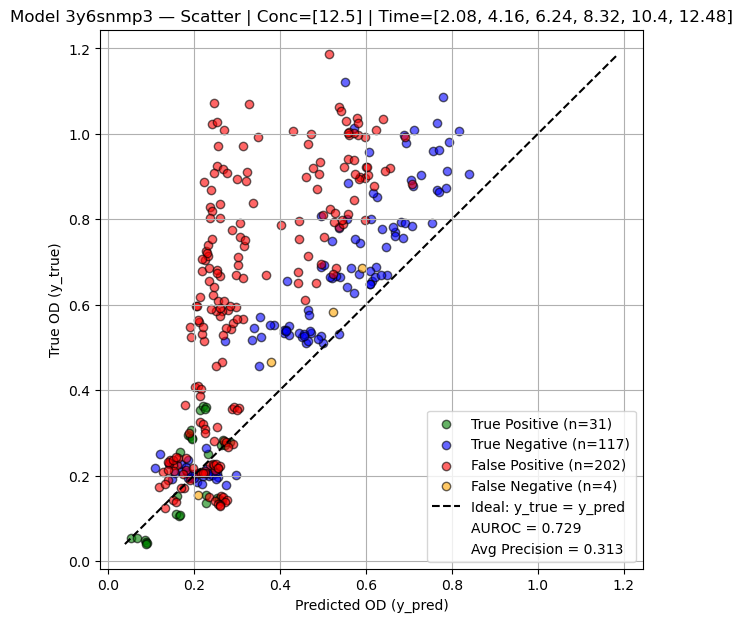

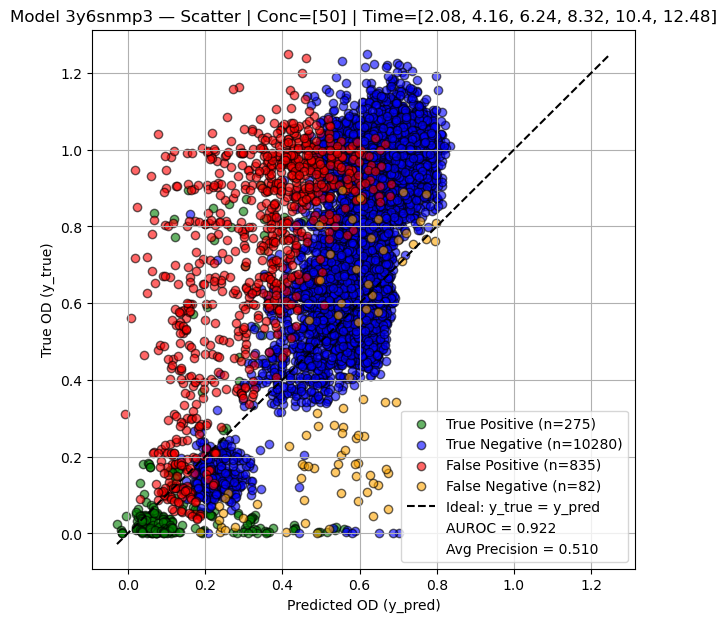

In [7]:

for c in [0.2,0.781,3.13,1.2,7.9,12.5,50]:
    plot_model_scatter_from_df(
        df_val=df_val,
        model=model,
        run_id=run_id,
        ExplicitDataset=ExplicitDataset,
        custom_collate=custom_collate,
        batch_to_tensor=batch_to_tensor,
        feature_set=hparams['feature_set'],
        num_fourier=3,
        device="cuda",
        concentrations=[c],
        timepoints=None,
        threshold=0.5,
        save=False
    )

In [24]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm

def plot_all_predicted_growth_curves_dense_df(
    df_dense,
    model,
    run_id,
    ExplicitDataset,
    custom_collate,
    batch_to_tensor,
    feature_set="minimol",
    num_fourier=3,
    device="cuda",
    concentrations=None,
    group_col="Compound",
    linewidth=1.0,
    alpha=0.15,
    save=False
):
    """
    Plot predicted growth curves for pre-generated dense dataframe.

    Assumes df_dense already contains all desired timepoints and concentrations.
    This function just filters by concentration(s), runs inference, and plots.

    Args:
        df_dense (pd.DataFrame): Dense validation dataframe with compound/fingerprint data.
        model (torch.nn.Module): Trained model.
        run_id (str): Model/run identifier.
        ExplicitDataset (Dataset): Dataset class for inference.
        custom_collate (callable): Collate function for DataLoader.
        batch_to_tensor (callable): Converts collated dict to tensors.
        num_fourier (int): Fourier encoding dimension.
        device (str): "cuda" or "cpu".
        concentrations (list or None): List of concentrations to include. Defaults to all.
        group_col (str): Column name grouping compounds ('Compound' or 'Smiles').
        linewidth (float): Line width for curves.
        alpha (float): Transparency of lines.
        save (bool or str): If True/str, save to file; else show interactively.
    """
    model.eval()

    # ---- Filter concentrations ----
    if concentrations is None:
        concentrations = sorted(df_dense["Concentration"].unique())

    df_subset = df_dense[df_dense["Concentration"].isin(concentrations)].reset_index(drop=True)
    if df_subset.empty:
        print("⚠️ No data available for selected concentrations.")
        return

    print(f"🧪 Using concentrations: {concentrations}")
    print(f"Subset shape: {df_subset.shape}")

    # ---- Dataset + Inference ----
    ds_test = ExplicitDataset(df_subset, num_fourier=num_fourier)
    test_loader = DataLoader(ds_test, batch_size=len(ds_test), collate_fn=custom_collate)

    print("📦 Converting dataframe to tensors...")
    for dict_test in tqdm(test_loader, desc="Building tensor dictionary"):
        Xte, _, _ = batch_to_tensor(dict_test, torch.device(device), feature_set=feature_set)

    print("🚀 Running model inference...")
    with torch.no_grad():
        y_reg_pred, _ = model(Xte.to(device))

    # ---- Attach predictions ----
    df_pred = df_subset.copy()
    df_pred["OD_pred"] = y_reg_pred.cpu().numpy().ravel()

    # ---- Plot all compounds ----
    plt.figure(figsize=(8, 6))
    for compound in tqdm(df_pred[group_col].unique(), desc="Plotting all compounds"):
        df_c = df_pred[df_pred[group_col] == compound]

        for c in sorted(df_c["Concentration"].unique()):
            df_cc = df_c[df_c["Concentration"] == c].sort_values("Timepoint")
            if df_cc.empty:
                continue

            plt.plot(
                df_cc["Timepoint"],
                df_cc["OD_pred"],
                color="blue",
                linewidth=linewidth,
                alpha=alpha,
            )

    # ---- Labels ----
    conc_str = ", ".join(map(str, concentrations))
    plt.title(f"{run_id} — Predicted Validation Growth Curves\nConcs: [{conc_str}]")
    plt.xlabel("Timepoint (h)")
    plt.ylabel("Predicted OD")
    plt.grid(True, alpha=0.2)
    plt.tight_layout()

    # ---- Save or show ----
    if save:
        if isinstance(save, str):
            save_path = save
        else:
            save_dir = f"/home/ethan2/GrowthCurve/plots/evaluate_models/{run_id}"
            os.makedirs(save_dir, exist_ok=True)
            conc_tag = "_".join(map(str, concentrations))
            save_path = os.path.join(save_dir, f"Validation_dense_growth_curves_conc_{conc_tag}.png")

        plt.savefig(save_path, bbox_inches="tight", dpi=300)
        plt.close()
        print(f"✅ Saved dense predicted growth curves at {save_path}")
    else:
        plt.show()


In [25]:
df_val_dense['Concentration'].unique()

array([ 1.2 , 50.  ,  7.9 ,  0.2 ,  3.13, 12.5 ])

In [26]:
for c in [0.2,1.2,3.13,7.9,12.5]:
    plot_all_predicted_growth_curves_dense_df(
        df_dense=df_val_dense,
        model=model,
        run_id=run_id,
        ExplicitDataset=ExplicitDataset,
        custom_collate=custom_collate,
        batch_to_tensor=batch_to_tensor,
        feature_set=hparams['feature_set'],
        num_fourier=3,
        device="cuda",
        concentrations=[c],   # e.g. plot only 1.2 µM
        linewidth=1.0,
        alpha=0.15,
        save=False
    )




🧪 Using concentrations: [0.2]
Subset shape: (53055, 14)
📦 Converting dataframe to tensors...


Building tensor dictionary:   0%|          | 0/1 [00:00<?, ?it/s]


TypeError: must be real number, not NoneType

In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm

def plot_all_predicted_concentration_curves(
    df_val,
    model,
    run_id,
    ExplicitDataset,
    custom_collate,
    batch_to_tensor,
    feature_set="minimol",
    num_fourier=3,
    device="cuda",
    timepoints=None,
    group_col="Compound",
    linewidth=1.0,
    alpha=0.15,
    save=False,
    atol=1e-6
):
    """
    Plot predicted OD vs Concentration for all compounds at a given timepoint (log-scale x-axis).
    Automatically uses all available concentrations per compound.
    Saves figure to:
        /home/ethan2/GrowthCurve/plots/evaluate_models/{run_id}/growthcurves_fixed_time_{time}.png

    Args:
        df_val (pd.DataFrame): Validation dataframe with OD, Timepoint, Concentration, Compound, etc.
        model (torch.nn.Module): Trained model for inference.
        run_id (str): Identifier for the model/run.
        ExplicitDataset (Dataset class): Dataset class used for inference.
        custom_collate (callable): Collate function for DataLoader.
        batch_to_tensor (callable): Converts collated dict to tensors.
        num_fourier (int): Fourier encoding dimension.
        device (str): 'cuda' or 'cpu'.
        timepoints (list or array): Single-element list or array containing the target timepoint.
        group_col (str): Column name grouping compounds ('Compound' or 'Smiles').
        linewidth (float): Line width for curves.
        alpha (float): Transparency of lines.
        save (bool): Whether to save the figure.
        atol (float): Float tolerance for timepoint filtering.
    """
    model.eval()

    # ---- Expect only one timepoint ----
    if timepoints is None or len(timepoints) == 0:
        raise ValueError("Please provide exactly one timepoint in 'timepoints'.")
    t = float(timepoints[0])

    print(f"\n⏱️ Plotting predicted OD vs concentration at Timepoint = {t} h")

    # ---- Filter dataframe ----
    df_t = df_val[df_val["Timepoint"] == t]
    if df_t.empty:
        print(f"⚠️ No data found for timepoint {t}")
        return

    # ---- Dataset + Inference ----
    ds_test = ExplicitDataset(df_t, num_fourier=num_fourier)
    test_loader = DataLoader(ds_test, batch_size=len(ds_test), collate_fn=custom_collate)
    dict_test = next(iter(test_loader))
    Xte, y_reg, y_cls = batch_to_tensor(dict_test, torch.device(device), feature_set=feature_set)

    with torch.no_grad():
        y_reg_pred, _ = model(Xte.to(device))

    # ---- Attach predictions ----
    df_pred = df_t.copy().reset_index(drop=True)
    df_pred["OD_pred"] = y_reg_pred.cpu().numpy().ravel()
    df_pred["Timepoint"] = df_pred["Timepoint"].astype(float)
    df_pred["Concentration"] = df_pred["Concentration"].astype(float)

    # ---- Plot all compounds ----
    plt.figure(figsize=(8, 6))
    drew_any = False

    for compound in tqdm(df_pred[group_col].unique(), desc="Plotting all compounds"):
        df_c = df_pred[df_pred[group_col] == compound].sort_values("Concentration")
        if df_c.empty:
            continue

        plt.plot(
            df_c["Concentration"],
            df_c["OD_pred"],
            color="blue",
            linewidth=linewidth,
            alpha=alpha,
        )
        drew_any = True

    if not drew_any:
        print(f"⚠️ No curves drawn at timepoint {t}.")
        return

    # ---- Labels ----
    plt.title(f"{run_id} — Predicted OD vs Concentration\nTimepoint: {t} h")
    plt.xlabel("log Concentration (µM)")
    plt.ylabel("Predicted OD")

    # ---- Log-scale x-axis ----
    plt.xscale("log")
    plt.xlim(0.2, 50)
    plt.grid(True, alpha=0.2, which="both")
    plt.tight_layout()

    # ---- Save or Show ----
    if save:
        save_dir = f"/home/ethan2/GrowthCurve/plots/evaluate_models/{run_id}"
        os.makedirs(save_dir, exist_ok=True)
        save_path = os.path.join(save_dir, f"all_growthcurves_all_concs_fixed_time_{t}.png")
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
        plt.close()
        print(f"✅ Saved growth curves at {save_path}")
    else:
        plt.show()


In [ ]:
plot_all_predicted_concentration_curves(
    df_val=df_val,
    model=model,
    run_id=run_id,
    ExplicitDataset=ExplicitDataset,
    custom_collate=custom_collate,
    batch_to_tensor=batch_to_tensor,
    feature_set=hparams['feature_set'],
    num_fourier=3,
    device="cuda",
    timepoints=[2.08],
    linewidth=1.0,
    alpha=0.15,
    save=False
)



⏱️ Plotting predicted OD vs concentration at Timepoint = 12.48 h


Plotting all compounds: 100%|██████████| 4926/4926 [00:04<00:00, 1152.30it/s]


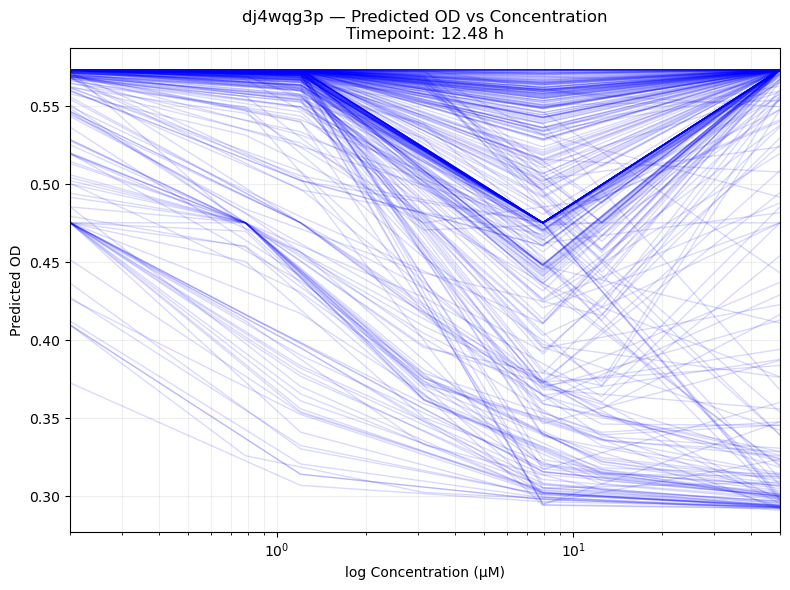

In [12]:
plot_all_predicted_concentration_curves(
    df_val=df_val,
    model=model,
    run_id=run_id,
    ExplicitDataset=ExplicitDataset,
    custom_collate=custom_collate,
    batch_to_tensor=batch_to_tensor,
    feature_set=hparams['feature_set'],
    num_fourier=3,
    device="cuda",
    timepoints=[12.48],
    linewidth=1.0,
    alpha=0.15,
    save=False
)

# Evaluate

/tmp/ipykernel_822797/3869339347.py:42: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  y_cls_true = np.array(y_cls_true).ravel().astype(int)


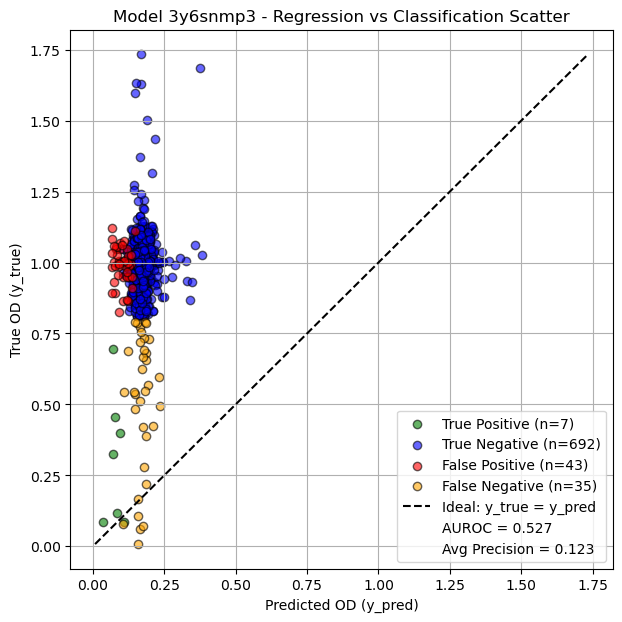

AUROC: 0.5273404599935212
AVPR: 0.12288550648278174
Pearson Correlation: 0.11421027


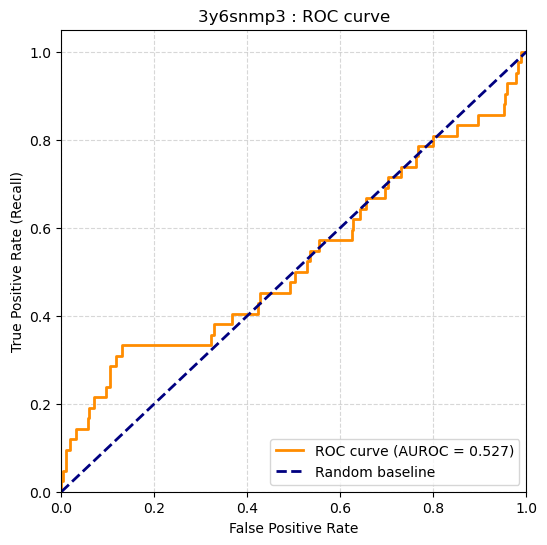

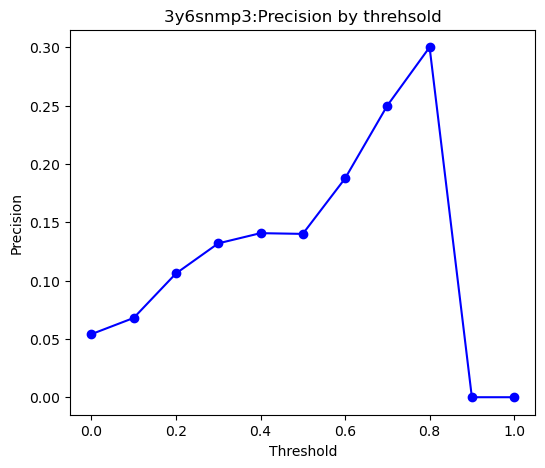

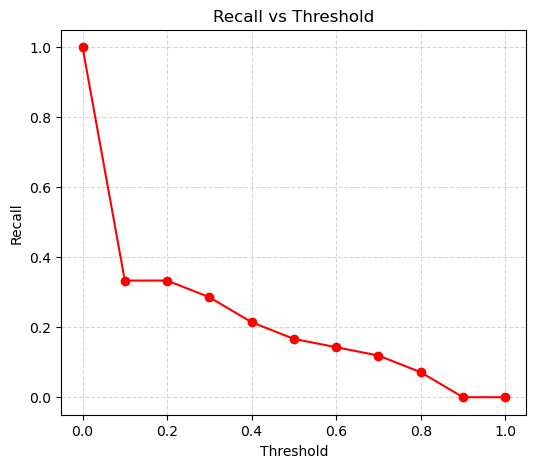

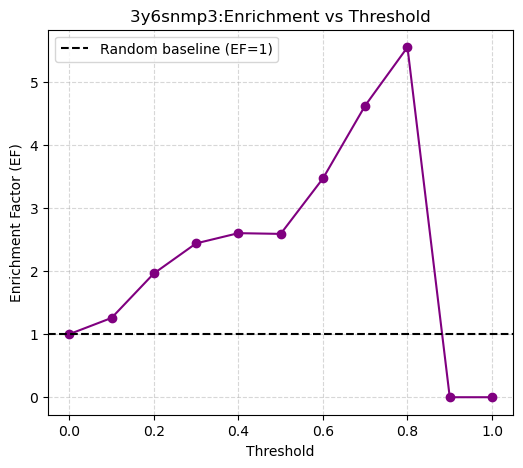

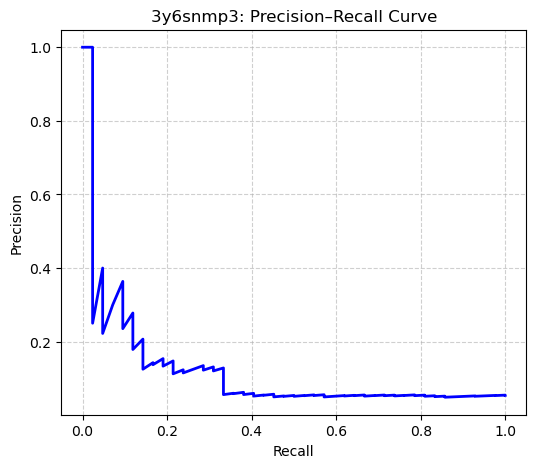

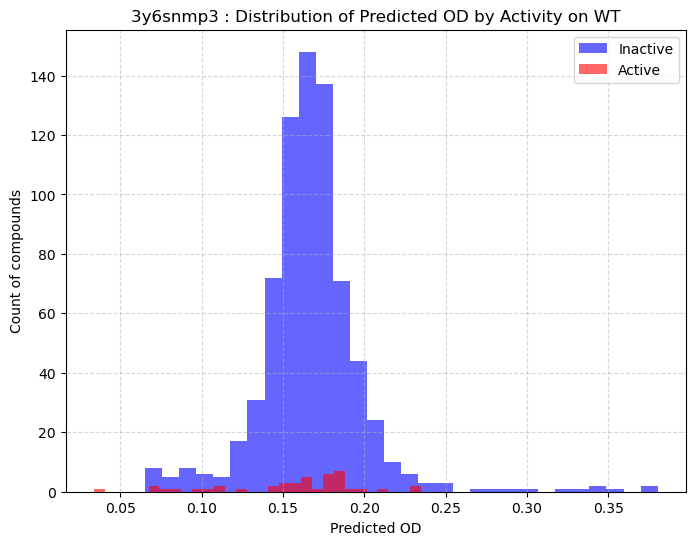

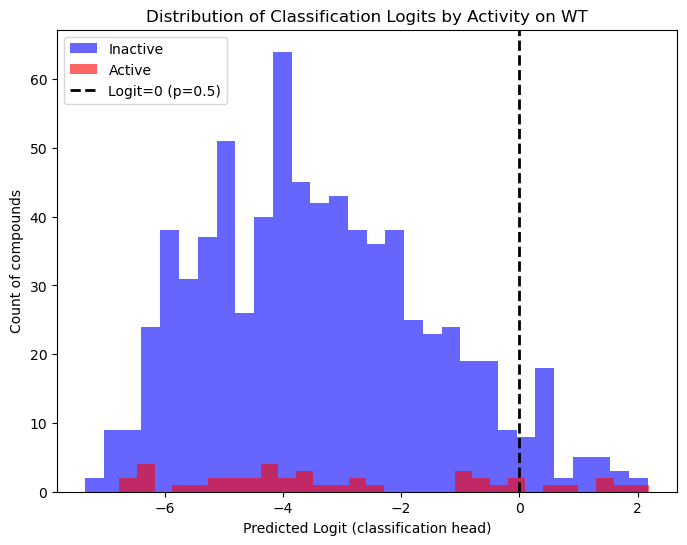

In [10]:

save=False
model.eval()
with torch.no_grad():
    y_reg_pred, y_cls_pred = model(Xte.to("cuda"))


# Regression targets
y_true = y_reg.cpu().numpy().ravel()
y_pred = y_reg_pred.cpu().numpy().ravel()

#results = get_misclassified_compounds(dict_test_WT_mean, y_cls_pred, threshold=0.5)

plot_regression_classification_scatter(
    y_true=y_true, 
    y_pred=y_pred, 
    y_cls_true=y_cls, 
    y_cls_pred=y_cls_pred, 
    threshold=0.5,
    run_id=run_id,
    save=save
)


# Convert labels and predictions
y_true = y_cls.cpu().numpy().ravel()
y_probs = get_probs(y_cls_pred)

# Metrics
auroc = compute_auroc(y_true, y_probs)
avpr = compute_avpr(y_true, y_probs)

# Pearson correlation
pearson_corr, _ = pearsonr(y_true, y_probs)

print("AUROC:", auroc)
print("AVPR:", avpr)
print("Pearson Correlation:", pearson_corr)


plot_roc_curve(y_true, y_probs, run_id=run_id, save=save)

thresholds = [0,0.1,0.2,0.3,0.4, 0.5, 0.6, 0.7, 0.8, 0.9,1]

plot_precision_by_threshold(y_true, y_probs, thresholds, run_id=run_id, save=save)
plot_recall_by_threshold(y_true, y_probs, thresholds,  run_id=run_id, save=save)
plot_enrichment_by_threshold(y_true, y_probs, thresholds, run_id=run_id, save=save)
plot_precision_recall_curve(y_true, y_probs, run_id, save=save)

plot_od_histogram(y_reg_pred, y_cls,run_id=run_id, save=save,bins=30)



plot_logit_histogram(y_cls_pred, y_cls,run_id=run_id, save=save, bins=30)

# Similarity of True Postivies and train compounds.

In [119]:
df_train = pd.read_pickle("/home/ethan2/GrowthCurve/data/train/df_well_train_mad_4.pkl")
df_train.columns

Index(['Well', 'Plate_ID', 'Concentration', 'Compound', 'Control_Label',
       'Smiles', 'Timepoint', 'OD', 'is_Active', 'scaffold', 'maccs_fp',
       'ecfp_fp', 'rdkit_fp'],
      dtype='object')

In [120]:
sorted(dict_test_WT_mean['features_by_family'].keys())

['ecfp_fp', 'maccs_fp', 'rdkit_fp']

In [124]:
y_reg,y_cls

(tensor([0.9288, 0.6765, 0.9552, 1.0136, 0.6285, 0.7880, 1.3581, 1.1244, 0.8921,
         0.4137, 0.8701, 0.7787, 0.9051, 1.0156, 0.9114, 0.6161, 1.0980, 1.0912,
         0.7861, 0.9783, 1.0764, 0.9218, 0.9588, 1.3653, 0.9659, 1.2881, 0.9899,
         1.1188, 0.6729, 1.0100, 0.6163, 1.1411, 0.8486, 0.8450, 1.0984, 1.2110,
         1.0825, 0.7657, 0.9108, 0.8360, 1.1645, 0.8568, 1.0742, 1.0370, 0.8512,
         0.8789, 1.0962, 1.0353, 0.7546, 0.9659, 1.0746, 0.8799, 1.0519, 1.0671,
         1.1787, 0.7752, 0.0595, 1.0955, 1.3114, 0.6827, 0.8661, 1.0842, 1.1188,
         0.0657, 1.0685, 1.0185, 1.2289, 0.0427, 0.8966, 0.9293, 0.9987, 1.0482,
         0.8378, 0.9480, 0.0650, 0.7617, 0.9410, 1.0092, 0.9534, 1.1661, 1.0144,
         0.9683, 0.7439, 0.9847, 0.9526, 1.0249, 1.0370, 1.0102, 1.1331, 1.2210,
         0.9925, 1.1320, 0.8869, 0.9590, 0.9872, 0.7768, 0.9655, 1.1151, 0.7439,
         1.0807, 0.7601, 0.8916, 0.9999, 1.0742, 0.8677, 0.9367, 0.9836, 0.7661,
         0.8101, 0.9385, 0.7

In [134]:
import numpy as np
import pandas as pd

# --- Helper: Tanimoto for bit vectors ---
def tanimoto(fp1, fp2):
    a = fp1.astype(bool)
    b = fp2.astype(bool)
    c = np.logical_and(a, b).sum()
    union = np.logical_or(a, b).sum()
    return c / (a.sum() + b.sum() - c ) if union > 0 else 0.0

# --- Step 1. Ensure order matches model ---
fp_order = sorted(dict_test_WT_mean["features_by_family"].keys())  # ['ecfp_fp', 'maccs_fp', 'rdkit_fp']

def concat_test_fp(idx):
    return np.concatenate([
        dict_test_WT_mean["features_by_family"][fam][idx].cpu().numpy()
        for fam in fp_order
    ])

def concat_train_fp(row):
    return np.concatenate([row[fam] for fam in fp_order])

model.eval()
with torch.no_grad():
    y_reg_pred, y_cls_pred = model(Xte.to("cuda"))

    
# True labels (classification)
y_cls_true = y_cls.detach().cpu().numpy().ravel().astype(int)

# Predicted labels (classification)
y_cls_pred_labels = (get_probs(y_cls_pred).ravel() > 0.5).astype(int)

# True regression values
y_true_np = y_true.detach().cpu().numpy().ravel() if torch.is_tensor(y_true) else np.array(y_true).ravel()

# Predicted regression values
y_reg_pred_np = y_reg_pred.detach().cpu().numpy().ravel()

# Mask for true positives where OD < 0.5
tp_mask = (
    (y_cls_true == 1)
    & (y_cls_pred_labels == 1)
    & (y_true_np < 0.5)
    & (y_reg_pred_np < 0.5)
)

tp_indices = np.where(tp_mask)[0]
tp_smiles = np.array(dict_test_WT_mean["smiles"])[tp_indices]


tp_indices = np.where(tp_mask)[0]
tp_smiles = np.array(dict_test_WT_mean["smiles"])[tp_indices]




In [135]:
len(tp_indices)

0

In [ ]:
tp_fps = np.stack([concat_test_fp(i) for i in tp_indices])

# --- Step 3. Deduplicate training compounds ---
train_compounds = df_train.drop_duplicates(subset=["Smiles"])
train_smiles = train_compounds["Smiles"].values
train_fps = np.stack([concat_train_fp(row) for _, row in train_compounds.iterrows()])

# --- Step 4. Compute Top-5 Similarities ---
results = []
for smi, fp_test in zip(tp_smiles, tp_fps):
    sims = np.array([tanimoto(fp_test, fp_train) for fp_train in train_fps])
    top_idx = sims.argsort()[::-1][:5]
    for rank, idx in enumerate(top_idx, start=1):
        results.append({
            "test_smiles": smi,
            "rank": rank,
            "train_smiles": train_smiles[idx],
            "tanimoto": sims[idx]
        })

df_results = pd.DataFrame(results)

In [123]:
df_results

,test_smiles,rank,train_smiles,tanimoto
0,[O-][N+](c1ccc(/C=N/c(cccc2)c2Cl)[o]1)=O,1,O=C(N/N=C/C1=CC=C([N+]([O-])=O)O1)N,0.530670
1,[O-][N+](c1ccc(/C=N/c(cccc2)c2Cl)[o]1)=O,2,O=C(N/N=C/C1=CC=C([N+]([O-])=O)O1)C2=CC=C(O)C=C2,0.469679
2,[O-][N+](c1ccc(/C=N/c(cccc2)c2Cl)[o]1)=O,3,CCNC=1N=C(NCC)N=C(NN=CC2=CC=C(O2)[N+](=O)[O-])N1,0.467703
3,[O-][N+](c1ccc(/C=N/c(cccc2)c2Cl)[o]1)=O,4,O=C1NC(CN1/N=C/C2=CC=C([N+]([O-])=O)O2)=O,0.432933
4,[O-][N+](c1ccc(/C=N/c(cccc2)c2Cl)[o]1)=O,5,O=C(N/N=C/C1=CC=C([N+]([O-])=O)O1)C2=CC([N+]([...,0.392070
...,...,...,...,...
85,CCN(C=C(C(O)=O)C(c1c2)=O)c1cc(N(CC1)CCN1C(Nc(c...,1,CCN1C=C(C(=O)OCC(=O)N2C(C)CCCC2C)C(=O)C=3C=C(F...,0.774804
86,CCN(C=C(C(O)=O)C(c1c2)=O)c1cc(N(CC1)CCN1C(Nc(c...,2,CC(=O)N1CCN(CC1)C=2C=C3N(C=C(C(=O)OCC=4C=CC=C(...,0.761658
87,CCN(C=C(C(O)=O)C(c1c2)=O)c1cc(N(CC1)CCN1C(Nc(c...,3,O=C(C1=CN(C2CC2)C3=C(C=C(F)C(N4CC(N)CC4)=C3Cl)...,0.732165
88,CCN(C=C(C(O)=O)C(c1c2)=O)c1cc(N(CC1)CCN1C(Nc(c...,4,O=C(C(C1=O)=CN2CCSC3=C(N4CCN(C)CC4)C(F)=CC1=C2...,0.706235


In [ ]:
import pandas as pd

# Save results to CSV
output_path = "/home/ethan2/GrowthCurve/data/TP_train_similarity.csv"
df_results.to_csv(output_path, index=False)

output_path

'/home/ethan2/GrowthCurve/data/TP_train_similarity.csv'